<a href="https://colab.research.google.com/github/ElizabethFrankWebb/USRI-2026/blob/main/Individual_Base_Model_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as ns

In [23]:
import numpy as np
#@title parameters

intial_population = 100
loci = 5
selection = 10
carrying_capacity = 100
optimal_trait_value = 0
optimal_growth_rate = 1.025
mutation_rate = 10**-2
generation = 1000 #@param {type:"integer"}
genotypes = np.zeros((intial_population, loci))

In [24]:
# Calculate trait value for all individuals

def calculate_trait_z(individual_genotype):
  trait_value = np.sum(individual_genotype)
  return trait_value
trait_values = np.array([calculate_trait_z(individual) for individual in genotypes])

print("Trait values for all individuals:")
print(trait_values)


Trait values for all individuals:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


In [25]:
def calculate_fitness(trait_values, optimal_trait_value, selection, current_population_size, carrying_capacity, optimal_growth_rate):
  trait_values = np.asarray(trait_values)

  genetic_fitness = np.exp(optimal_growth_rate * ((1 - current_population_size / carrying_capacity) - (trait_values - optimal_trait_value)**2 / (2 * selection)))
  expected_offspring_per_individual = genetic_fitness * (optimal_growth_rate - (optimal_growth_rate - 1) * (current_population_size / carrying_capacity))
  return np.maximum(0, expected_offspring_per_individual)


population_fitness = calculate_fitness(trait_values, optimal_trait_value, selection, len(trait_values), carrying_capacity, optimal_growth_rate)

print(population_fitness)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]


In [26]:
def recombine(parent1_genotype, parent2_genotype, loci):
  """Performs 50% inheritance recombination between two parent genotypes."""
  offspring_genotype = np.zeros(loci)
  for i in range(loci):
    if np.random.rand() < 0.5: # 50% chance to inherit from parent1
      offspring_genotype[i] = parent1_genotype[i]
    else:
      offspring_genotype[i] = parent2_genotype[i]
  return offspring_genotype

# parent selection, recombination, and offspring generation


if len(genotypes) > 0:

    individual_indices = np.arange(len(genotypes))

    # Normalize population_fitness to create valid probabilities for parent selection.
    sum_fitness = np.sum(population_fitness)

    if sum_fitness == 0:
        print("Cannot select parents for demonstration: all individuals have zero fitness.")
    else:
        probabilities = population_fitness / sum_fitness

        # Select two parents based on their fitness probabilities
        chosen_parent_indices = np.random.choice(
            individual_indices,
            size=2,
            p=probabilities,
            replace=True # Parents can be selected multiple times, and self-mating is allowed
        )

        parent1_genotype = genotypes[chosen_parent_indices[0]]
        parent2_genotype = genotypes[chosen_parent_indices[1]]

        # Perform recombination
        offspring_genotype = recombine(parent1_genotype, parent2_genotype, loci)

        # Print the results
        print(f"Selected Parent 1 Genotype: {parent1_genotype}")
        print(f"Selected Parent 2 Genotype: {parent2_genotype}")
        print(f"Offspring Genotype (after recombination): {offspring_genotype}")
else:
    print("No individuals in the population to perform mating demonstration.")

Selected Parent 1 Genotype: [0. 0. 0. 0. 0.]
Selected Parent 2 Genotype: [0. 0. 0. 0. 0.]
Offspring Genotype (after recombination): [0. 0. 0. 0. 0.]


In [27]:
#next generation poisson distrbution for number of offsring


lambdas = population_fitness

offspring_counts = np.random.poisson(lambdas)

print(offspring_counts)

[1 1 1 1 3 4 1 2 0 0 0 1 1 2 1 2 2 1 2 2 1 1 1 1 3 1 0 1 1 0 1 1 3 0 2 1 1
 1 1 1 0 2 0 0 2 1 3 1 0 2 1 0 1 1 1 1 1 2 3 0 0 2 0 0 0 1 0 1 2 1 2 0 1 1
 0 0 2 3 1 1 2 1 0 0 0 0 2 1 0 2 0 2 0 0 0 1 2 1 2 0]


In [28]:
# introducing mutation

def mutate(individual, mutation_rate):
  mutated_individual = individual.copy()
  mutated_loci_info = []
  for locus in range(len(individual)):
    if np.random.rand() < mutation_rate:
      original_value = individual[locus]
      new_value = np.random.normal(0,1)
      mutated_individual[locus] = new_value
      mutated_loci_info.append((locus, original_value, new_value))
  return mutated_individual, mutated_loci_info

In [29]:
def recombine(parent1_genotype, parent2_genotype, loci):
  """Performs 50% inheritance recombination between two parent genotypes."""
  offspring_genotype = np.zeros(loci)
  for i in range(loci):
    if np.random.rand() < 0.5: # 50% chance to inherit from parent1
      offspring_genotype[i] = parent1_genotype[i]
    else:
      offspring_genotype[i] = parent2_genotype[i]
  return offspring_genotype

In [30]:
# Generate the next generation with mutations
new_gen_genotypes_list = []
offspring_mutation_details = []
offspring_counter = 0

# Ensure intial_population is updated to reflect the current size of genotypes array
current_population_size = len(genotypes)

for parent_idx in range(current_population_size):
    parent_genotype = genotypes[parent_idx]
    num_offspring = offspring_counts[parent_idx]

    for _ in range(num_offspring):
        mutated_individual, mutated_loci_info = mutate(parent_genotype, mutation_rate)
        new_gen_genotypes_list.append(mutated_individual)

        if mutated_loci_info:
            offspring_mutation_details.append({
                'offspring_idx': offspring_counter,
                'parent_idx': parent_idx,
                'mutations': mutated_loci_info
            })
        offspring_counter += 1

# Update the genotypes for the new generation
if new_gen_genotypes_list:
    genotypes = np.array(new_gen_genotypes_list)
    intial_population = len(genotypes) # Update population size for the next generation
else:
    genotypes = np.empty((0, loci)) # Handle case with no offspring
    intial_population = 0

print("--- New Generation Genotypes with Mutations ---")
if intial_population > 0:
    for i, individual_genotype in enumerate(genotypes):
        print(f"Offspring {i}: Genotype = {individual_genotype}")
else:
    print("No offspring were generated in this generation.")

print("\n--- Mutation Details ---")
if offspring_mutation_details:
    for detail in offspring_mutation_details:
        print(f"Offspring {detail['offspring_idx']} (from Parent {detail['parent_idx']}) mutated at:")
        for locus_idx, original_val, new_val in detail['mutations']:
            print(f"  Locus {locus_idx}: Changed from {original_val:.4f} to {new_val:.4f}")
else:
    print("No mutations occurred in this generation.")

# Recalculate trait values for the new generation
if intial_population > 0:
    trait_values = np.array([calculate_trait_z(individual) for individual in genotypes])
    print(f"\nRecalculated Trait values for new generation ({intial_population} individuals):")
    print(trait_values)

    # Recalculate fitness for the new generation
    population_fitness = calculate_fitness(trait_values, optimal_trait_value, selection, intial_population, carrying_capacity, optimal_growth_rate)
    print(f"\nRecalculated Fitness for new generation ({intial_population} individuals):")
    print(population_fitness)
else:
    print("\nCannot recalculate trait values or fitness as no offspring were generated.")

--- New Generation Genotypes with Mutations ---
Offspring 0: Genotype = [0. 0. 0. 0. 0.]
Offspring 1: Genotype = [0. 0. 0. 0. 0.]
Offspring 2: Genotype = [0. 0. 0. 0. 0.]
Offspring 3: Genotype = [0. 0. 0. 0. 0.]
Offspring 4: Genotype = [0. 0. 0. 0. 0.]
Offspring 5: Genotype = [0. 0. 0. 0. 0.]
Offspring 6: Genotype = [0. 0. 0. 0. 0.]
Offspring 7: Genotype = [0. 0. 0. 0. 0.]
Offspring 8: Genotype = [0. 0. 0. 0. 0.]
Offspring 9: Genotype = [0. 0. 0. 0. 0.]
Offspring 10: Genotype = [0. 0. 0. 0. 0.]
Offspring 11: Genotype = [0. 0. 0. 0. 0.]
Offspring 12: Genotype = [0. 0. 0. 0. 0.]
Offspring 13: Genotype = [0. 0. 0. 0. 0.]
Offspring 14: Genotype = [0. 0. 0. 0. 0.]
Offspring 15: Genotype = [0. 0. 0. 0. 0.]
Offspring 16: Genotype = [0. 0. 0. 0. 0.]
Offspring 17: Genotype = [0. 0. 0. 0. 0.]
Offspring 18: Genotype = [0. 0. 0. 0. 0.]
Offspring 19: Genotype = [ 0.          0.          0.         -1.07640576  0.        ]
Offspring 20: Genotype = [0. 0. 0. 0. 0.]
Offspring 21: Genotype = [1.5347510

### Simulation Loop

In [31]:
fitness_history = [] # Initialize list to store fitness data for each generation
trait_value_history = [] # Initialize list to store trait value data for each generation

# Initial fitness and trait value calculation for the very first generation (before any loops)
initial_trait_values = np.array([calculate_trait_z(individual) for individual in genotypes])
current_pop_size = len(genotypes) # Initial population size
population_fitness = calculate_fitness(initial_trait_values, optimal_trait_value, selection, current_pop_size, carrying_capacity, optimal_growth_rate)
fitness_history.append(population_fitness.copy())
trait_value_history.append(initial_trait_values.copy())

for g in range(generation):
    # Check for population extinction from the previous generation
    if len(genotypes) == 0:
        for _ in range(g, generation):
            fitness_history.append(np.array([]))
            trait_value_history.append(np.array([]))
        break

    # Calculate fitness for the *current* parent population to use for parent selection
    current_parent_population_size = len(genotypes);
    if current_parent_population_size == 0:
        # Population already extinct, fill remaining generations and break
        for _ in range(g, generation):
            fitness_history.append(np.array([]))
            trait_value_history.append(np.array([]))
        break

    parent_trait_values = np.array([calculate_trait_z(individual) for individual in genotypes])
    parent_population_fitness = calculate_fitness(parent_trait_values, optimal_trait_value, selection, current_parent_population_size, carrying_capacity, optimal_growth_rate)

    # Handle case where all parents have zero fitness (extinction)
    if np.all(parent_population_fitness == 0):
        genotypes = np.empty((0, loci))
        current_pop_size = 0
        population_fitness = np.array([]) # Indicate extinction for next generation
        fitness_history.append(population_fitness.copy())
        trait_value_history.append(np.array([]))
        for _ in range(g + 1, generation):
            fitness_history.append(np.array([]))
            trait_value_history.append(np.array([]))
        break

    # Prepare for parent selection
    individual_indices = np.arange(current_parent_population_size)
    sum_parent_fitness = np.sum(parent_population_fitness)

    # If sum_parent_fitness is zero (due to numerical issues, etc.), treat as extinction
    if sum_parent_fitness == 0:
        genotypes = np.empty((0, loci))
        current_pop_size = 0
        population_fitness = np.array([])
        fitness_history.append(population_fitness.copy())
        trait_value_history.append(np.array([]))
        for _ in range(g + 1, generation):
            fitness_history.append(np.array([]))
            trait_value_history.append(np.array([]))
        break

    probabilities = parent_population_fitness / sum_parent_fitness

    # Determine the number of offspring to generate for the next generation.
    # In sexual reproduction, the total number of offspring for the next generation
    # is determined by the total reproductive output of the current population.
    # We use the sum of fitness values as the expected total number of offspring.
    total_offspring_to_generate = int(np.sum(parent_population_fitness))

    # If no offspring are expected, the population goes extinct
    if total_offspring_to_generate == 0:
        genotypes = np.empty((0, loci))
        current_pop_size = 0
        population_fitness = np.array([])
        fitness_history.append(population_fitness.copy())
        trait_value_history.append(np.array([]))
        for _ in range(g + 1, generation):
            fitness_history.append(np.array([]))
            trait_value_history.append(np.array([]))
        break

    # --- Generate the next generation (offspring) via sexual reproduction ---
    new_gen_genotypes_list = []
    offspring_mutation_details = []
    offspring_counter = 0

    for _ in range(total_offspring_to_generate):
        # Select two parents based on their fitness probabilities
        chosen_parent_indices = np.random.choice(
            individual_indices,
            size=2,
            p=probabilities,
            replace=True
        )
        parent1_genotype = genotypes[chosen_parent_indices[0]]
        parent2_genotype = genotypes[chosen_parent_indices[1]]

        # Perform recombination
        offspring_genotype_recombined = recombine(parent1_genotype, parent2_genotype, loci)

        # Apply mutation
        mutated_individual, mutated_loci_info = mutate(offspring_genotype_recombined, mutation_rate)
        new_gen_genotypes_list.append(mutated_individual)

        # Print parent and offspring genotypes (for demonstration, limited to first gen, few offspring)
        if g == 0 and offspring_counter < 10: # Print for first 10 offspring in generation 0
            print(f"Gen {g}: Parent1: {parent1_genotype}, Parent2: {parent2_genotype}, Offspring: {mutated_individual}")

        if mutated_loci_info:
            offspring_mutation_details.append({
                'offspring_idx': offspring_counter,
                'parent1_idx': chosen_parent_indices[0],
                'parent2_idx': chosen_parent_indices[1],
                'mutations': mutated_loci_info
            })
        offspring_counter += 1

    # Update genotypes for the new generation
    if new_gen_genotypes_list:
        genotypes = np.array(new_gen_genotypes_list)
    else:
        genotypes = np.empty((0, loci))

    current_pop_size = len(genotypes)

    # Recalculate fitness and trait values for the *newly generated population*
    # This updated 'population_fitness' and 'trait_values' will be used as the base for the next iteration
    if current_pop_size > 0:
        trait_values = np.array([calculate_trait_z(individual) for individual in genotypes])
        population_fitness = calculate_fitness(trait_values, optimal_trait_value, selection, current_pop_size, carrying_capacity, optimal_growth_rate)
    else:
        trait_values = np.array([])
        population_fitness = np.array([])

    fitness_history.append(population_fitness.copy())
    trait_value_history.append(trait_values.copy())


Gen 0: Parent1: [0. 0. 0. 0. 0.], Parent2: [0. 0. 0. 0. 0.], Offspring: [0. 0. 0. 0. 0.]
Gen 0: Parent1: [0. 0. 0. 0. 0.], Parent2: [0. 0. 0. 0. 0.], Offspring: [0.20387738 0.         0.         0.         0.        ]
Gen 0: Parent1: [0. 0. 0. 0. 0.], Parent2: [0.         0.         0.40251749 0.         0.        ], Offspring: [0. 0. 0. 0. 0.]
Gen 0: Parent1: [0. 0. 0. 0. 0.], Parent2: [0. 0. 0. 0. 0.], Offspring: [0. 0. 0. 0. 0.]
Gen 0: Parent1: [0. 0. 0. 0. 0.], Parent2: [0. 0. 0. 0. 0.], Offspring: [0. 0. 0. 0. 0.]
Gen 0: Parent1: [0. 0. 0. 0. 0.], Parent2: [0. 0. 0. 0. 0.], Offspring: [0. 0. 0. 0. 0.]
Gen 0: Parent1: [0. 0. 0. 0. 0.], Parent2: [0. 0. 0. 0. 0.], Offspring: [0. 0. 0. 0. 0.]
Gen 0: Parent1: [0. 0. 0. 0. 0.], Parent2: [0. 0. 0. 0. 0.], Offspring: [0. 0. 0. 0. 0.]
Gen 0: Parent1: [0. 0. 0. 0. 0.], Parent2: [0. 0. 0. 0. 0.], Offspring: [0. 0. 0. 0. 0.]
Gen 0: Parent1: [0. 0. 0. 0. 0.], Parent2: [0. 0. 0. 0. 0.], Offspring: [0. 0. 0. 0. 0.]


/tmp/ipykernel_1959/3203444992.py:9: UserWarning: 

The `a` parameter has been replaced; use `x`, `y`, and/or `data` instead.
Please update your code; This will become an error in seaborn v0.14.0.

  ns.rugplot(a=final_generation_fitness, color="darkblue", height=0.05)


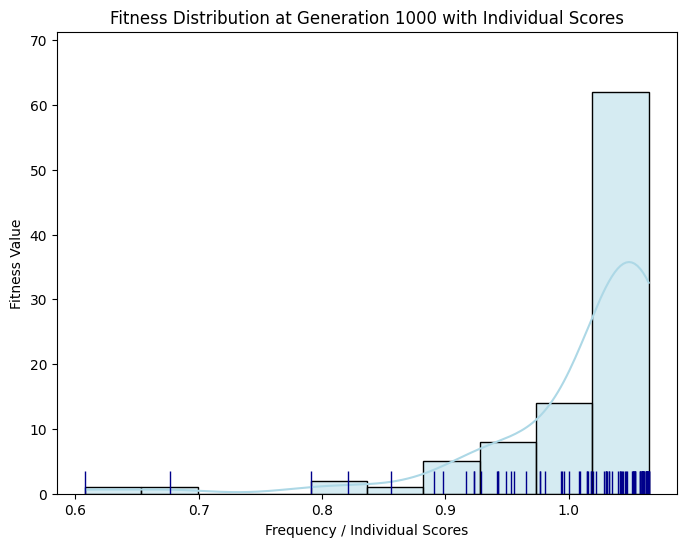

In [32]:
#Plotting the distribution of fitness values for the final generation

final_generation_fitness = fitness_history[-1]

if len(final_generation_fitness) > 0:
    plt.figure(figsize=(8, 6))
    ns.histplot(data=final_generation_fitness, bins=10, kde=True, color="lightblue")
    # Add rugplot to show individual fitness scores
    ns.rugplot(a=final_generation_fitness, color="darkblue", height=0.05)
    plt.title(f"Fitness Distribution at Generation {generation} with Individual Scores")
    plt.xlabel("Frequency / Individual Scores")
    plt.ylabel("Fitness Value")
    plt.show()
else:
    print(f"Population went extinct before or at Generation {generation}. No fitness data to plot.")

/tmp/ipykernel_1959/1059431385.py:9: UserWarning: 

The `a` parameter has been replaced; use `x`, `y`, and/or `data` instead.
Please update your code; This will become an error in seaborn v0.14.0.

  ns.rugplot(a=final_generation_trait_value, color="darkblue", height=0.05)


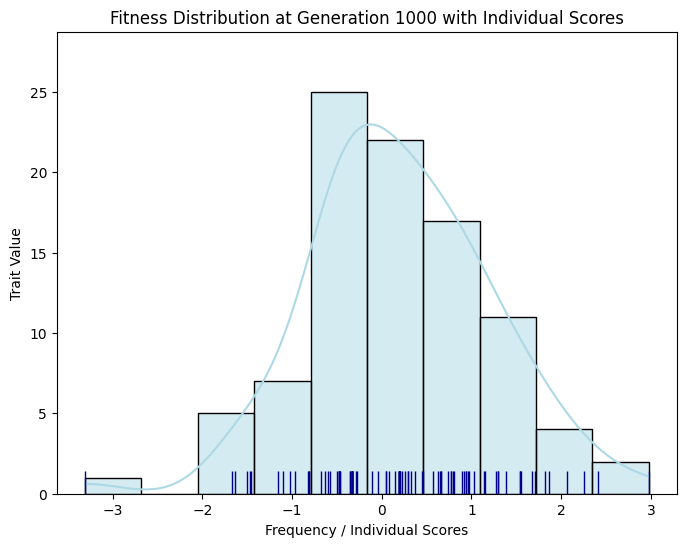

In [33]:
#ploting Trait Value for the population

final_generation_trait_value = trait_value_history[-1]

if len(final_generation_trait_value) > 0:
    plt.figure(figsize=(8, 6))
    ns.histplot(data=final_generation_trait_value, bins=10, kde=True, color="lightblue")
    # Add rugplot to show individual fitness scores
    ns.rugplot(a=final_generation_trait_value, color="darkblue", height=0.05)
    plt.title(f"Fitness Distribution at Generation {generation} with Individual Scores")
    plt.xlabel("Frequency / Individual Scores")
    plt.ylabel("Trait Value")
    plt.show()
else:
    print(f"Population went extinct before or at Generation {generation}. No fitness data to plot.")